In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import matplotlib.lines as mlines

In [2]:
# Read in clustering results
cd8_t = pd.read_csv('../data/cd8_t_cells_cd8_low_cells_removed_clustering_results_patient_updated.csv', index_col = 0)
cd8_t.columns = cd8_t.columns.str.replace('FlowSOM_metacluster_ ', '')
cd8_t.columns = cd8_t.columns.str.replace('Unnamed: 0', 'Sample')
cd8_t['Sample'] = cd8_t['Patient_ID'] + '_' + cd8_t['time'].str.replace('_', '')
cd8_t['Sample'] = cd8_t['Sample'].str.replace('_Control', '')

In [3]:
# Delete spare progression sample (there was a second later measurement which was associated with progression)
# Delete sample 61290 006 as the patient went off trial due to participant preference
cd8_t = cd8_t.loc[cd8_t['Sample'] != 'P02_SPD',:]
cd8_t = cd8_t.loc[~cd8_t['Sample'].str.contains('P26'),:]
cd8_t['Sample'] = cd8_t['Sample'].str.replace('P02_SPD_2', 'P02_SPD')

# Delete the following samples as they have only a single measurement
print(cd8_t.shape)
cd8_t = cd8_t.loc[~cd8_t['Sample'].str.contains('P27'),:]
print(cd8_t.shape)

(115, 43)
(114, 43)


In [4]:
cd8_t.columns

Index(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13',
       '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25',
       '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37',
       '38', '39', '40', 'Patient_ID', 'time', 'Sample'],
      dtype='object')

In [5]:
# Read in annotation results which are in an excel sheet
annotations = pd.read_excel('../data/2024_06_25_Annotations.xlsx')

# Create a dictionary to map each cell type to a cluster
annotations_dict = {}
for i in annotations['Annotation'].unique():
    a = annotations.loc[annotations['Annotation'] == i,:]
    annotations_dict[i] = a['FlowSOM_Cluster'].astype(str).to_list()
    #print(a)

annotations_dict

{'CD56pos_GzmBpos': ['1',
  '2',
  '3',
  '4',
  '5',
  '8',
  '12',
  '14',
  '15',
  '20',
  '40'],
 'CD56neg_GzmBpos': ['6',
  '7',
  '9',
  '10',
  '11',
  '16',
  '21',
  '22',
  '24',
  '25',
  '28',
  '29',
  '32',
  '34',
  '38'],
 'CD56pos_CD127neg_Trm': ['13', '19', '23', '26'],
 'Activated': ['17', '39'],
 'CD56pos_CD127pos_Trm': ['18'],
 'CD56neg_CD127neg_Trm': ['27', '30'],
 'Memory': ['31', '36', '37'],
 'CD56neg_CD127pos_Trm': ['33'],
 'Naïve/Memory': ['35']}

In [6]:
# Create a function which sums the columns which are part of each cell type
def add_columns(df, sum_dict):
    for new_col, cols_to_sum in sum_dict.items():
        df[new_col] = df[cols_to_sum].sum(axis=1)
    return df

In [7]:
# Add the columns together using the function specified in the cell above
cd8_t = add_columns(cd8_t, annotations_dict)

# Delete the spare columns to make for simpler reading
cd8_t = cd8_t.drop(cd8_t.loc[:,'1':'40'], axis = 1)    
cd8_t.head()

,Patient_ID,time,Sample,CD56pos_GzmBpos,CD56neg_GzmBpos,CD56pos_CD127neg_Trm,Activated,CD56pos_CD127pos_Trm,CD56neg_CD127neg_Trm,Memory,CD56neg_CD127pos_Trm,Naïve/Memory
0,P08,C1_D8,P08_C1D8,1114,7964,744,489,141,1032,696,186,615
1,P08,C7_D1,P08_C7D1,235,1108,290,253,69,434,281,87,256
2,P08,C7_D22,P08_C7D22,142,710,40,26,21,78,157,17,142
3,P08,SPD,P08_SPD,227,1218,37,19,22,67,202,8,183
4,P24,C1_D1,P24_C1D1,2539,4558,36,415,13,737,882,105,324


In [8]:
# Read in patient info sheet (this was sent to me by Julie on 2024_01_17)
patient_info = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx', sheet_name = 'Sheet1', nrows = 40)
patient_info = patient_info.loc[~patient_info['Outcome_C6_revised_Vid'].isna(), :]
patient_info['PID'] = patient_info['PID'].astype(str)

# Create dictionaries so that I can add information to the dataframe such as diagnosis and clinical outcomes

diagnosis_dx = {}
for x, y in zip(patient_info['PID'], patient_info['Diagnosis']):
    diagnosis_dx[x] = y
diagnosis_dx

outcome_C6_dx = {}
for x, y in zip(patient_info['PID'], patient_info['Outcome_C6_revised_Vid']):
    outcome_C6_dx[x] = y
outcome_C6_dx 

outcome_C12_dx = {}
for x, y in zip(patient_info['PID'], patient_info['Outcome_C12_CC486']):
    outcome_C12_dx[x] = y


In [9]:
# Use the dictionaries to add clinical outcomes to the dataframe
cd8_t['diagnosis'] = cd8_t['Patient_ID'].map(diagnosis_dx)
cd8_t['outcome_6'] = cd8_t['Patient_ID'].map(outcome_C6_dx)
cd8_t['outcome_12'] = cd8_t['Patient_ID'].map(outcome_C12_dx)

cd8_t.head()

,Patient_ID,time,Sample,CD56pos_GzmBpos,CD56neg_GzmBpos,CD56pos_CD127neg_Trm,Activated,CD56pos_CD127pos_Trm,CD56neg_CD127neg_Trm,Memory,CD56neg_CD127pos_Trm,Naïve/Memory,diagnosis,outcome_6,outcome_12
0,P08,C1_D8,P08_C1D8,1114,7964,744,489,141,1032,696,186,615,MDS,non-responder_2,non-responder_2
1,P08,C7_D1,P08_C7D1,235,1108,290,253,69,434,281,87,256,MDS,non-responder_2,non-responder_2
2,P08,C7_D22,P08_C7D22,142,710,40,26,21,78,157,17,142,MDS,non-responder_2,non-responder_2
3,P08,SPD,P08_SPD,227,1218,37,19,22,67,202,8,183,MDS,non-responder_2,non-responder_2
4,P24,C1_D1,P24_C1D1,2539,4558,36,415,13,737,882,105,324,AML,non-responder_2,NaN


In [10]:
# Read in the total number of cells acquired in the T cell panel
total_num = pd.read_csv('../data/t_cell_panel_clustering_results_patient_updated.csv', index_col=0)
total_num.columns = total_num.columns.str.replace('FlowSOM_metacluster_V1', 'Sample')
total_num['Sample'] = total_num['Sample'].str.replace('_T_Cell_Panel', '')
total_num['cell_number'] = total_num.loc[:,'FlowSOM_metacluster_1':'FlowSOM_metacluster_9'].sum(axis=1)

total_num['Sample'] = total_num['Sample'].str.replace('_D', 'D')
print(total_num.shape)
# # # Read in a dataframe which details the number of myeloid cells 
# # # so that I can figure out how to control for the number of stem and progenitor cells in each sample
hspc = pd.read_csv('../data/myeloid_panel_patient_metacluster_table_patient_updated.csv', index_col=0)
hspc['total_cells'] = hspc.loc[:, 'metacluster_1':'metacluster_9'].sum(axis = 1) #'metacluster_1''metacluster_2' metacluster_3 metacluster_9
hspc['hspc_lsc'] = hspc[['metacluster_1', 'metacluster_2', 'metacluster_3', 'metacluster_9']].sum(axis=1) # these coliumns are HSPC and aberrant

hspc['ratio_hspc_lsc'] = hspc.loc[:, 'hspc_lsc'].divide(hspc.loc[:, 'total_cells'], axis =0)
hspc['multiplication_factor'] = 1 - hspc.loc[:, 'ratio_hspc_lsc'] 
hspc['PID_Timepoint'] = hspc['FileNames'].str.replace('_Myeloid_Panel', '').str.replace('_C1_', '_C1').str.replace('_C7_', '_C7').str.replace('_C12_', '_C12')
hspc = hspc.loc[:, ['PID_Timepoint', 'multiplication_factor']]

# # # Create a dataframe which details the corrected cell number in each dataframe
total_num = pd.merge(total_num, hspc, left_on = 'Sample', right_on = 'PID_Timepoint')
total_num['corrected_cell_num'] = (total_num['cell_number'] * total_num['multiplication_factor']).astype(int)
total_num = total_num.loc[:, ['Sample', 'cell_number', 'corrected_cell_num']]
print(total_num.shape)

(118, 42)
(118, 3)


In [11]:
# Add the corrected cell number to the dataframe
cells1 = pd.merge(cd8_t, total_num, left_on = 'Sample', right_on = 'Sample')
print(cells1.shape)

(113, 17)


In [12]:
# Add a column called best response which details the best clinical response of each patient
# if a patient is called a responder at any timepont they are called a responder even if they eventually progress
best_response = []
for x, y, z in zip(cells1['outcome_6'], cells1['outcome_12'], cells1['Patient_ID']):
    if (x == 'responder_1') | (y == 'responder_1'):
        best_response.append('responder')
    elif 'Control' in z:
        best_response.append('Control')
    else:
        best_response.append('non-responder')

cells1['best_response'] = best_response
cells1.shape

(113, 18)

In [13]:
# Delete the following samples as they have a weird number of CD34+ cells which don't make sense when combined with 
# the myeloid object
print(cells1.shape)
cells1 = cells1.loc[(cells1['Sample'] != 'P04_C1_D1') & (cells1['Sample'] != 'P14_C1_D1'), :]
print(cells1.shape)

(113, 18)
(113, 18)


In [14]:
# Replace the number of cells with a percentage
cols = cells1.loc[:, 'CD56pos_GzmBpos':'Naïve/Memory'].columns # create this list so it can be set to a float

cells1[cols] = cells1[cols].astype(float).divide(
    cells1['corrected_cell_num'].astype(float), axis=0
) * 100

cells1.head()

,Patient_ID,time,Sample,CD56pos_GzmBpos,CD56neg_GzmBpos,CD56pos_CD127neg_Trm,Activated,CD56pos_CD127pos_Trm,CD56neg_CD127neg_Trm,Memory,CD56neg_CD127pos_Trm,Naïve/Memory,diagnosis,outcome_6,outcome_12,cell_number,corrected_cell_num,best_response
0,P08,C1_D8,P08_C1D8,1.398795,10.000000,0.934204,0.614013,0.177047,1.295831,0.873933,0.233551,0.772225,MDS,non-responder_2,non-responder_2,93394,79640,non-responder
1,P08,C7_D1,P08_C7D1,1.440127,6.790048,1.777179,1.550435,0.422846,2.659640,1.722025,0.533154,1.568820,MDS,non-responder_2,non-responder_2,18835,16318,non-responder
2,P08,C7_D22,P08_C7D22,1.513537,7.567683,0.426348,0.277126,0.223833,0.831379,1.673417,0.181198,1.513537,MDS,non-responder_2,non-responder_2,9829,9382,non-responder
3,P08,SPD,P08_SPD,1.837015,9.856761,0.299425,0.153759,0.178037,0.542203,1.634701,0.064741,1.480942,MDS,non-responder_2,non-responder_2,13073,12357,non-responder
4,P24,C1_D1,P24_C1D1,10.990390,19.729894,0.155831,1.796381,0.056272,3.190200,3.817851,0.454506,1.402476,AML,non-responder_2,NaN,35288,23102,non-responder


In [15]:
cells1.head()

,Patient_ID,time,Sample,CD56pos_GzmBpos,CD56neg_GzmBpos,CD56pos_CD127neg_Trm,Activated,CD56pos_CD127pos_Trm,CD56neg_CD127neg_Trm,Memory,CD56neg_CD127pos_Trm,Naïve/Memory,diagnosis,outcome_6,outcome_12,cell_number,corrected_cell_num,best_response
0,P08,C1_D8,P08_C1D8,1.398795,10.000000,0.934204,0.614013,0.177047,1.295831,0.873933,0.233551,0.772225,MDS,non-responder_2,non-responder_2,93394,79640,non-responder
1,P08,C7_D1,P08_C7D1,1.440127,6.790048,1.777179,1.550435,0.422846,2.659640,1.722025,0.533154,1.568820,MDS,non-responder_2,non-responder_2,18835,16318,non-responder
2,P08,C7_D22,P08_C7D22,1.513537,7.567683,0.426348,0.277126,0.223833,0.831379,1.673417,0.181198,1.513537,MDS,non-responder_2,non-responder_2,9829,9382,non-responder
3,P08,SPD,P08_SPD,1.837015,9.856761,0.299425,0.153759,0.178037,0.542203,1.634701,0.064741,1.480942,MDS,non-responder_2,non-responder_2,13073,12357,non-responder
4,P24,C1_D1,P24_C1D1,10.990390,19.729894,0.155831,1.796381,0.056272,3.190200,3.817851,0.454506,1.402476,AML,non-responder_2,NaN,35288,23102,non-responder


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-p

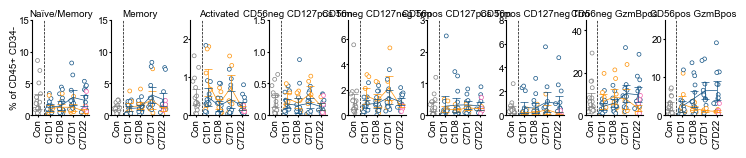

In [16]:
# Create figure with all 9 subsets

color_dict = {'non-responder':'#fe9003', 'responder':'#115284', 'Control': 'grey'}

figure_list = ['Naïve/Memory', 'Memory', 'Activated', 'CD56neg_CD127pos_Trm', 'CD56neg_CD127neg_Trm',  
               'CD56pos_CD127pos_Trm', 'CD56pos_CD127neg_Trm', 'CD56neg_GzmBpos',  'CD56pos_GzmBpos']

timepoint_dict = {'C1_D1' : 2, 'C1_D8' : 3, 'C7_D1': 4, 'C7_D22' : 5, 'C12_D29' : 6, 'Progression' : 7, 'Control': 1}
cells1['time1'] = cells1['time'].map(timepoint_dict)


cells2 = cells1.copy()
cells2 = cells2.loc[cells2['time'] != 'C12_D29', :]

# Set font to be used in the graphs
plt.rcParams["font.family"] = "Arial" # export font as editable text
 
plt.rcParams['pdf.fonttype'] = 42 # export font as editable text

# Create graphs
fig, axs = plt.subplots(1, 9, figsize = (7.5, 6.69 * 0.25))
#axs_flatten = axs.flatten()

jitter_amount = 0.75  # Adjust the jitter amount as needed
x_jitter = np.random.normal(1, jitter_amount, size = cells2.shape[0])
timejitter =  []

# Create a list with the ids of the patients who progressed in my dataset. Note that all my patients
# where I have a progression sample, progressed during the oral phase of the trial
stars = cells2.loc[cells2['time'] == 'SPD', 'Patient_ID'].to_list()

for z, (w, x, y) in enumerate(zip(cells2['time1'], cells2['Patient_ID'], x_jitter)): 
        if (w == 5) & (x in stars): 
            timejitter.append(w + (y/10))
        elif z % 2 == 0:
            timejitter.append(w + (y/10))
        else:
            timejitter.append(w - (y/10))

    
cells2['time2'] = timejitter

# Create a dataframe which contains the progression samples so that I can add stars
# to each point where there is a 

stars1 = cells2.loc[(cells2['Patient_ID'].isin(stars)) &  (cells2['time'] == 'C7_D22'), :]
cells3 = cells2.loc[cells2['time'] != 'Progression',:]

for x, ax in enumerate(axs):
    ax.scatter(x = cells3.loc[:,'time2'], y = cells3.loc[:, figure_list[x]], 
              c = 'white', edgecolor= cells3.loc[:,'best_response'].map(color_dict), s =8, lw = 0.5)
    sns.lineplot(data=cells3, 
        x='time1', 
                 y=figure_list[x], 
        errorbar=('sd', 0.5),
        err_style='bars',
        err_kws={'linewidth': 0.5, 'capsize':3, 'capthick': 0.5},# combines errorbar type and capsize
        legend=False,
        hue='best_response',
        palette=color_dict, 
        linewidth=0.5, 
        ax=ax)
    
    ax.scatter(x = stars1['time2'], y = stars1[figure_list[x]], c = 'white', s =8, lw = 0.5, edgecolor = 'hotpink')

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_ylim(bottom = 0)
    ax.set_xlabel('')
    
    e = str(figure_list[x])
    e = e.replace('_', ' ')
    
    ax.set_title(str(e), fontsize = 7, y = 0.95)
    
    if x == 0:
        ax.set_ylabel('% of CD45+ CD34-', fontsize = 7, labelpad = 0)
    else:
        ax.set_ylabel('')

    
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(['Con', 'C1D1', 'C1D8', 'C7D1', 'C7D22'], rotation = 90, fontsize = 7)
    ax.axvline(1.5, ls = '--', color = 'black', linewidth = 0.5)
    ax.tick_params(axis='both', labelsize=7, pad = 0.25, length = 1.5)
    
    if (x == 0) | (x ==1) :
        ax.set_ylim(bottom=0, top=15)
    if x == 2:
        ax.set_ylim(bottom=0, top=2.5)
    if x == 3:
        ax.set_ylim(bottom=0, top=1.5)
    if x == 4:
        ax.set_ylim(bottom=0, top=7.5)
    if x == 5:
        ax.set_ylim(bottom=0, top=3)
    if x == 6:
        ax.set_ylim(bottom=0, top=8)
    if x == 7:
        ax.set_ylim(bottom=0, top=45)
    if x == 8:
        ax.set_ylim(bottom=0, top=25)
                            
        
plt.tight_layout(w_pad=0.025)
# fig.savefig('../results_2_v2/figure_2_second_part_3.png', bbox_inches = 'tight', pad_inches=0.01, dpi = 600)
# fig.savefig('../results_2_v2/figure_2_second_part_3.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600)